In [90]:
import pandas as pd

In [91]:
df = pd.read_csv('Restaurant_Reviews.tsv', sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [92]:
df.shape

(1000, 2)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  1000 non-null   str  
 1   Liked   1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB


In [94]:
# 1. Calculate null sum
count_null = df.isnull().sum()

# 2. Transform into a DataFrame and rename columns
df_nulls = count_null.reset_index()
df_nulls.columns = ['Column', 'Null_Count']

# 3. Add percentage column for quick analysis
df_nulls['Percentage (%)'] = (df_nulls['Null_Count'] / len(df)) * 100

# Sort by most nulls
df_nulls = df_nulls.sort_values(by='Null_Count', ascending=False)

df_nulls

,Column,Null_Count,Percentage (%)
0,Review,0,0.0
1,Liked,0,0.0


In [95]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import layers

# --- PRE-CLEANING (Important to avoid conversion errors) ---
# Ensure no null values exist and force everything to string type
df['Review'] = df['Review'].fillna('').astype(str)

# 1. Preparing Labels (Restaurant Ratings)
le = LabelEncoder()
y = le.fit_transform(df['Liked']) 
num_classes = len(le.classes_)

# 2. Splitting the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df['Review'], y, test_size=0.2, random_state=42
)

# --- DTYPE CORRECTION: Converting to String Tensors ---
# This ensures TensorFlow recognizes the input as a valid string array
X_train_tensor = tf.convert_to_tensor(X_train.values, dtype=tf.string)
X_test_tensor = tf.convert_to_tensor(X_test.values, dtype=tf.string)

# 3. Text Vectorization Layer (Converts words to integers)
max_tokens = 100000 
sequence_length = 200 

vectorize_layer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)
# Adapt the layer using the training string tensor
vectorize_layer.adapt(X_train_tensor)

# 4. Neural Network Architecture (CPU-friendly for i5 processors)
model = tf.keras.Sequential([
    vectorize_layer,
    layers.Embedding(max_tokens, 64, mask_zero=True),
    layers.GlobalAveragePooling1D(), # Reduces complexity for faster CPU training
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2), # Helps prevent overfitting
    layers.Dense(num_classes, activation='softmax') # Final decision layer
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Training (Using the corrected tensors) - Capturing history for visualization
history = model.fit(
    X_train_tensor, 
    y_train, 
    epochs=5, 
    validation_data=(X_test_tensor, y_test), 
    batch_size=32
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5925 - loss: 0.6880 - val_accuracy: 0.6900 - val_loss: 0.6827
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8138 - loss: 0.6501 - val_accuracy: 0.7600 - val_loss: 0.6513
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8775 - loss: 0.5614 - val_accuracy: 0.7800 - val_loss: 0.5854
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9237 - loss: 0.4128 - val_accuracy: 0.7750 - val_loss: 0.5103
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9575 - loss: 0.2605 - val_accuracy: 0.7950 - val_loss: 0.4577


In [96]:
import numpy as np
import random

In [97]:
# Model evaluation
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test_tensor, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_pred_probs = model.predict(X_test_tensor[:len(X_test_tensor)], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Show sample predictions
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for i in random.sample(range(1, len(X_test_tensor)),k=10):
    predicted_rating = le.inverse_transform([y_pred[i]])[0]
    actual_rating = le.inverse_transform([y_test[i]])[0]
    confidence = y_pred_probs[i][y_pred[i]]
    
    print(f"\n--- Review {i} ---")
    print(f"Review Text: {X_test.iloc[i][:150]}...")
    print(f"Predicted Rating: {predicted_rating} (Confidence: {confidence*100:.2f}%)")
    print(f"Actual Rating: {actual_rating}")
    print(f"Result: {'✓ Correct' if predicted_rating == actual_rating else '✗ Incorrect'}")

MODEL EVALUATION

Test Loss: 0.4577
Test Accuracy: 0.7950 (79.50%)

SAMPLE PREDICTIONS

--- Review 169 ---
Review Text: Fantastic food!...
Predicted Rating: 1 (Confidence: 92.84%)
Actual Rating: 1
Result: ✓ Correct

--- Review 89 ---
Review Text: They could serve it with just the vinaigrette and it may make for a better overall dish, but it was still very good....
Predicted Rating: 1 (Confidence: 64.39%)
Actual Rating: 1
Result: ✓ Correct

--- Review 110 ---
Review Text: This was my first time and I can't wait until the next....
Predicted Rating: 1 (Confidence: 81.36%)
Actual Rating: 1
Result: ✓ Correct

--- Review 84 ---
Review Text: And considering the two of us left there very full and happy for about $20, you just can't go wrong....
Predicted Rating: 1 (Confidence: 60.34%)
Actual Rating: 1
Result: ✓ Correct

--- Review 97 ---
Review Text: Omelets are to die for!...
Predicted Rating: 0 (Confidence: 65.54%)
Actual Rating: 1
Result: ✗ Incorrect

--- Review 159 ---
Review Text: On thre

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

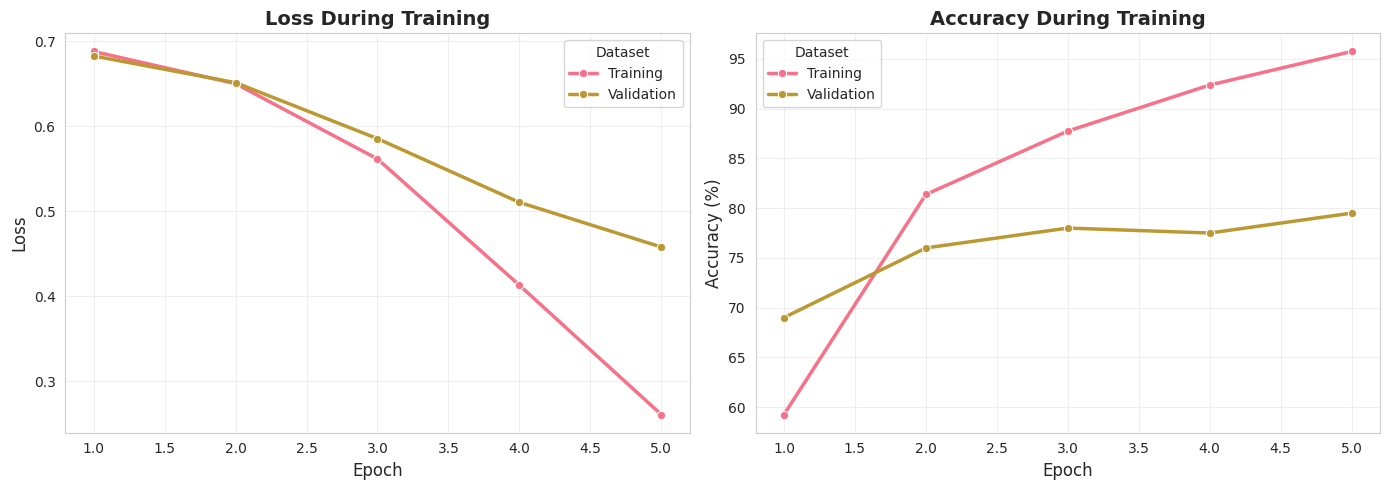


TRAINING SUMMARY

Initial Loss:      0.6880
Final Loss:        0.2605
Reduction:         62.13%

Initial Accuracy:  59.25%
Final Accuracy:    95.75%
Improvement:       36.50%

Validation Accuracy: 79.50%


In [99]:
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert history to DataFrame for Seaborn usage
history_df = pd.DataFrame(history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['loss'],
    'Type': 'Training'
})
val_loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['val_loss'],
    'Type': 'Validation'
})
combined_loss = pd.concat([loss_data, val_loss_data], ignore_index=True)

sns.lineplot(data=combined_loss, x='Epoch', y='Loss', hue='Type', 
             ax=axes[0], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Dataset')

# Plot 2: Accuracy
acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['accuracy'] * 100,
    'Type': 'Training'
})
val_acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['val_accuracy'] * 100,
    'Type': 'Validation'
})
combined_acc = pd.concat([acc_data, val_acc_data], ignore_index=True)

sns.lineplot(data=combined_acc, x='Epoch', y='Accuracy', hue='Type', 
             ax=axes[1], linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Dataset')

plt.tight_layout()
plt.show()

# Training summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"\nInitial Loss:      {history.history['loss'][0]:.4f}")
print(f"Final Loss:        {history.history['loss'][-1]:.4f}")
print(f"Reduction:         {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")

print(f"\nInitial Accuracy:  {history.history['accuracy'][0]*100:.2f}%")
print(f"Final Accuracy:    {history.history['accuracy'][-1]*100:.2f}%")
print(f"Improvement:       {(history.history['accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%")

print(f"\nValidation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 80)

/tmp/ipykernel_25310/182895243.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_dist, x='variable', y='value', ax=axes[1, 1], palette='Set3')


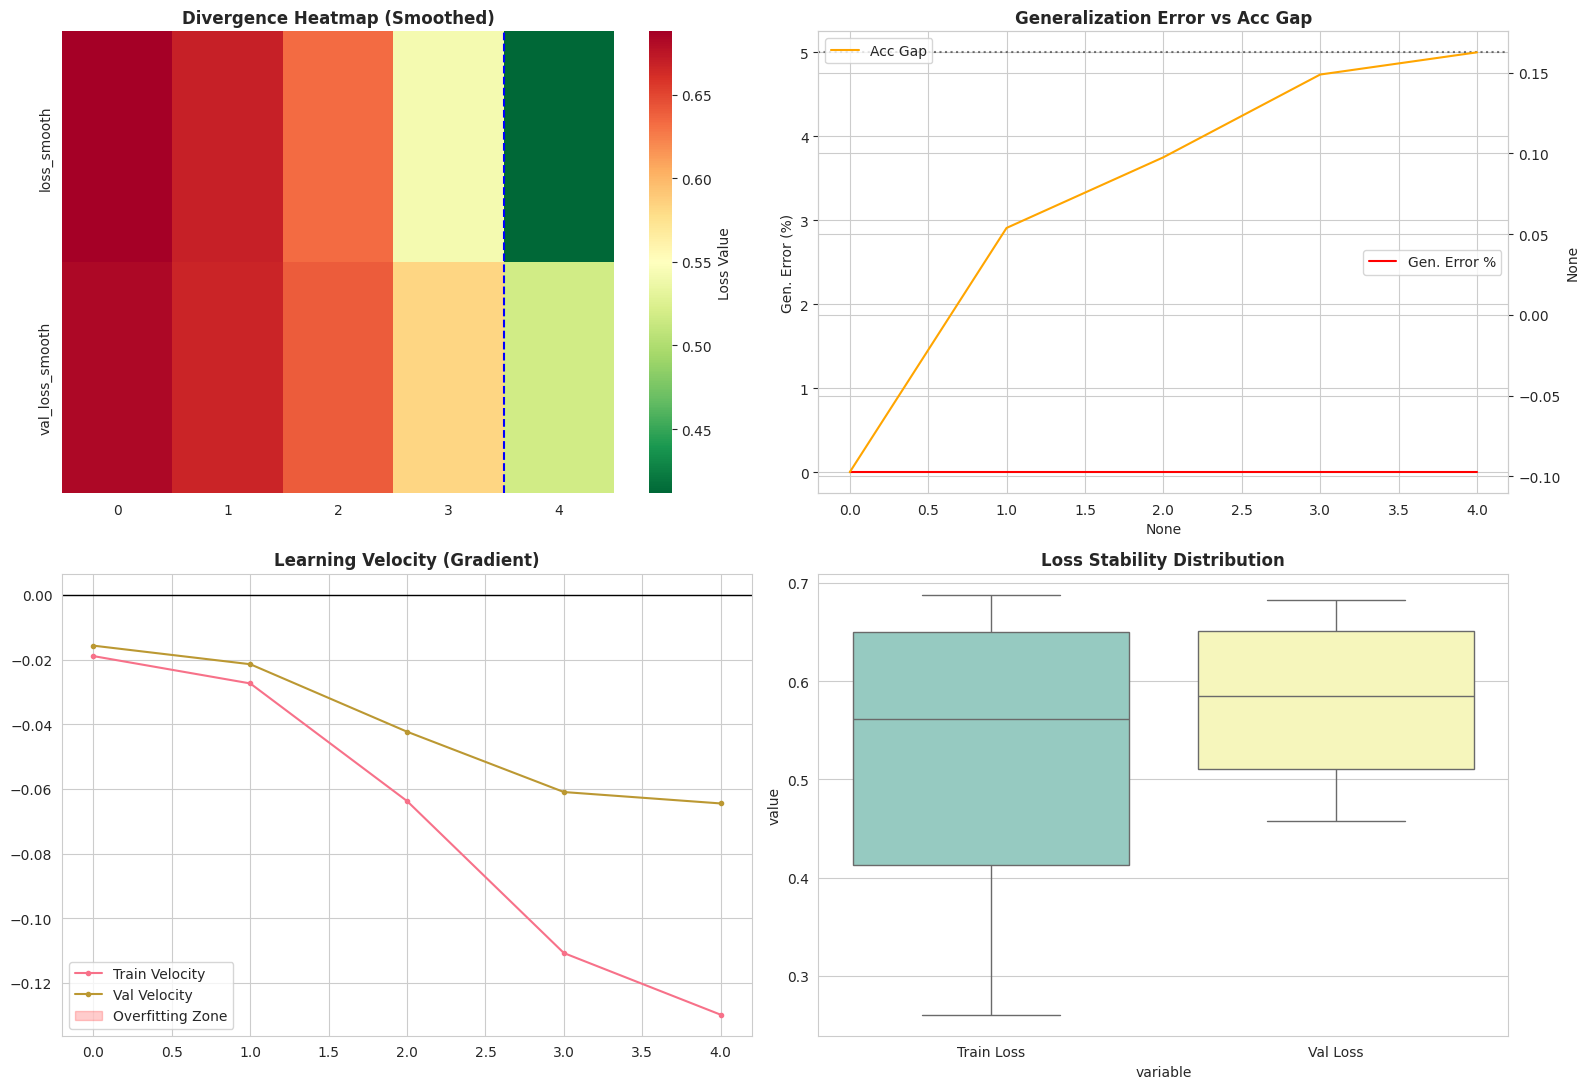


RELATÓRIO ESTATÍSTICO DE OVERFITTING
Melhor época encontrada: 4
Nenhum sinal crítico de overfitting detectado dentro dos limites.
STATUS: ✓ MODELO ESTÁVEL


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preparação dos Dados ---
# Supondo que 'history_df' já exista com colunas: loss, val_loss, accuracy, val_accuracy
df = history_df.copy()

# 1. Suavização (Rolling Mean) para evitar falsos positivos por ruído
window = 3
df['loss_smooth'] = df['loss'].rolling(window=window, min_periods=1).mean()
df['val_loss_smooth'] = df['val_loss'].rolling(window=window, min_periods=1).mean()

# 2. Cálculo da Taxa de Generalização (G)
# G = 100 * (val_loss atual / min(val_loss até agora) - 1)
min_val_loss_so_far = df['val_loss'].cummin()
df['generalization_error'] = 100 * (df['val_loss'] / min_val_loss_so_far - 1)

# 3. Identificação do Ponto de Inflexão (Onde o overfitting começa de fato)
best_epoch = df['val_loss'].idxmin()
overfit_epoch = df[(df.index > best_epoch) & (df['generalization_error'] > 5)].index.min()

# --- Visualização ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Heatmap de Perda Suavizada (Focado em Divergência)
metrics_heatmap = df[['loss_smooth', 'val_loss_smooth']].T
sns.heatmap(metrics_heatmap, cmap='RdYlGn_r', ax=axes[0, 0], cbar_kws={'label': 'Loss Value'})
axes[0, 0].set_title('Divergence Heatmap (Smoothed)', fontweight='bold')
axes[0, 0].axvline(x=best_epoch, color='blue', linestyle='--', label='Best Model')

# Plot 2: Gap de Acurácia e Erro de Generalização
ax2_twin = axes[0, 1].twinx()
sns.lineplot(data=df, x=df.index, y='generalization_error', ax=axes[0, 1], color='red', label='Gen. Error %')
sns.lineplot(data=df, x=df.index, y=df['accuracy'] - df['val_accuracy'], ax=ax2_twin, color='orange', label='Acc Gap')
axes[0, 1].axhline(y=5, color='black', linestyle=':', alpha=0.5) # Limiar de 5%
axes[0, 1].set_title('Generalization Error vs Acc Gap', fontweight='bold')
axes[0, 1].set_ylabel('Gen. Error (%)')

# Plot 3: Derivada da Perda (Velocidade de Aprendizado)
train_diff = np.gradient(df['loss_smooth'])
val_diff = np.gradient(df['val_loss_smooth'])
axes[1, 0].plot(df.index, train_diff, label='Train Velocity', marker='o', markersize=3)
axes[1, 0].plot(df.index, val_diff, label='Val Velocity', marker='o', markersize=3)
axes[1, 0].axhline(y=0, color='black', lw=1)
axes[1, 0].fill_between(df.index, val_diff, where=(val_diff > 0), color='red', alpha=0.2, label='Overfitting Zone')
axes[1, 0].set_title('Learning Velocity (Gradient)', fontweight='bold')
axes[1, 0].legend()

# Plot 4: Distribuição de Erro Relativo
error_dist = pd.DataFrame({
    'Train Loss': df['loss'],
    'Val Loss': df['val_loss']
}).melt()
sns.boxplot(data=error_dist, x='variable', y='value', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Loss Stability Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Relatório Final Aprimorado ---
print("\n" + "=" * 50)
print("RELATÓRIO ESTATÍSTICO DE OVERFITTING")
print("=" * 50)
print(f"Melhor época encontrada: {best_epoch}")
if not np.isnan(overfit_epoch):
    print(f"Overfitting crítico detectado na época: {overfit_epoch}")
    print(f"Degradação da Validação desde o mínimo: {df['generalization_error'].iloc[-1]:.2f}%")
else:
    print("Nenhum sinal crítico de overfitting detectado dentro dos limites.")

# Critério de Severidade
final_gap = df['val_loss'].iloc[-1] - df['loss'].iloc[-1]
if final_gap > 0.5:
    print("STATUS: ✗ OVERFITTING SEVERO - Requer redução de complexidade ou dropout.")
elif final_gap > 0.2:
    print("STATUS: ⚠ OVERFITTING MODERADO - Considere Early Stopping.")
else:
    print("STATUS: ✓ MODELO ESTÁVEL")